In [4]:
# !pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, recall_score, confusion_matrix, average_precision_score, 
                             precision_recall_curve, roc_auc_score, cohen_kappa_score, PrecisionRecallDisplay)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import Pipeline

## Load Data

In [6]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
# df = pd.read_csv('/kaggle/input/malnutrition/ch.csv')
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,status,province_Gandaki Province,province_Karnali Province,province_Province 1,province_Province 2,province_Province 5,province_Sudoorpaschim Province
0,1.0,-1.066081,0,0,0,1,2.0,1,1.0,1,0,0,1,0,0,0
1,3.0,0.434428,0,1,0,1,2.0,1,1.0,1,0,0,1,0,0,0


In [7]:
df.shape

(6552, 16)

In [8]:
df['status'].value_counts()

status
0    3535
1    3017
Name: count, dtype: int64

In [9]:
df.head()

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,status,province_Gandaki Province,province_Karnali Province,province_Province 1,province_Province 2,province_Province 5,province_Sudoorpaschim Province
0,1.0,-1.066081,0,0,0,1,2.0,1,1.0,1,0,0,1,0,0,0
1,3.0,0.434428,0,1,0,1,2.0,1,1.0,1,0,0,1,0,0,0
2,2.0,-0.012533,1,0,0,0,1.0,1,1.0,0,0,0,1,0,0,0
3,1.0,-0.587196,1,1,0,0,1.0,1,1.0,0,0,0,1,0,0,0
4,4.0,1.136794,0,0,0,0,1.0,1,1.0,0,0,0,1,0,0,0


## Data Preparation

In [10]:
# =====================
# 1. Prepare Data
# =====================
X = df.drop(columns=['status'])
y = df['status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# SMOTE oversampling
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# print("Before SMOTE:", Counter(y_train))
# print("After SMOTE:", Counter(y_train_sm))

## Base Model

In [11]:
# ===================
# 2. Base Model (SMOTE outside pipeline)
# ===================
base_knn = KNeighborsClassifier()
base_knn.fit(X_train_sm, y_train_sm)

y_pred_base = base_knn.predict(X_test)
y_proba_base = base_knn.predict_proba(X_test)[:, 1]
y_train_pred_base = base_knn.predict(X_train_sm)

# Scores for base model
print(confusion_matrix(y_test, y_pred_base))
print('------------------------------------------------------')
print(classification_report(y_test, y_pred_base, digits=3))
print('------------------------------------------------------')
print(f"Test Average Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
print(f"Training recall: {recall_score(y_train_sm, y_train_pred_base):.3f}")


[[463 244]
 [217 387]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.681     0.655     0.668       707
           1      0.613     0.641     0.627       604

    accuracy                          0.648      1311
   macro avg      0.647     0.648     0.647      1311
weighted avg      0.650     0.648     0.649      1311

------------------------------------------------------
Test Average Precision: 0.630
Test AUC: 0.696
Test Cohen's Kappa: 0.295
Training recall: 0.796


## Tuned Model

In [12]:
# ===================
# 3. Tuned Model (SMOTE inside pipeline with GridSearchCV)
# ===================
pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': range(1, 36, 2),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

grid_knn = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_knn.fit(X_train, y_train)  # Notice: no SMOTE here, pipeline handles SMOTE internally

best_knn = grid_knn.best_estimator_
y_pred_tuned = best_knn.predict(X_test)
y_proba_tune = best_knn.predict_proba(X_test)[:, 1]

# Scores for tuned model
print("Best Parameters:", grid_knn.best_params_)
print('------------------------------------------------------')
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned, digits=3))

y_train_pred_tuned = best_knn.predict(X_train)

print('------------------------------------------------------')
print(f"Test Average Precision: {average_precision_score(y_test, y_proba_tune):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_tune):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_tuned):.3f}")
print(f"Training recall: {recall_score(y_train, y_train_pred_tuned):.3f}")

Fitting 15 folds for each of 144 candidates, totalling 2160 fits
Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 29, 'knn__weights': 'uniform'}
------------------------------------------------------
[[464 243]
 [190 414]]
              precision    recall  f1-score   support

           0      0.709     0.656     0.682       707
           1      0.630     0.685     0.657       604

    accuracy                          0.670      1311
   macro avg      0.670     0.671     0.669      1311
weighted avg      0.673     0.670     0.670      1311

------------------------------------------------------
Test Average Precision: 0.709
Test AUC: 0.742
Test Cohen's Kappa: 0.340
Training recall: 0.723


### 95% CI on Recall for the tuned model

Recall 95% CI: (0.648, 0.720)


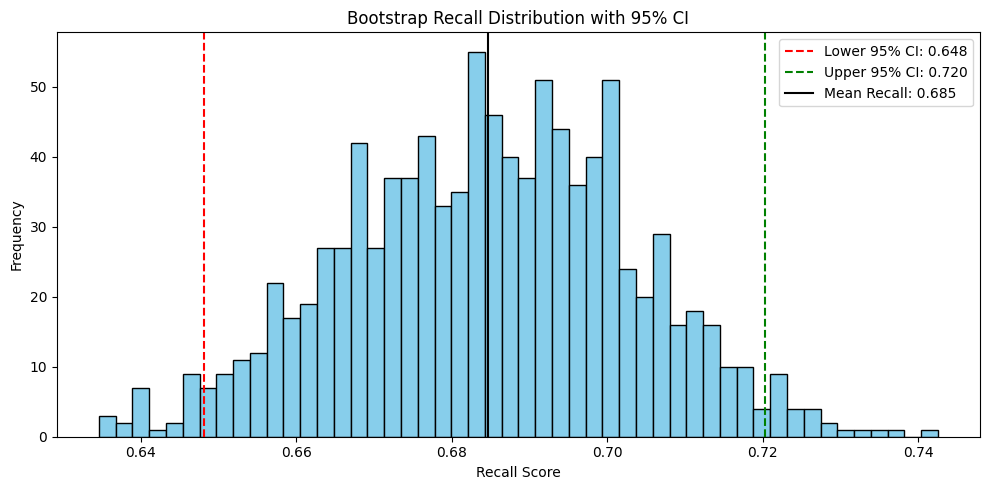

In [13]:
def bootstrap_ci_recall_distribution(y_true, y_pred_func, X, n_bootstraps=1000, alpha=0.95):
    rng = np.random.RandomState(42)
    bootstrapped_scores = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true.iloc[indices])) < 2:
            continue
        score = recall_score(y_true.iloc[indices], y_pred_func(X.iloc[indices]))
        bootstrapped_scores.append(score)
    sorted_scores = np.sort(bootstrapped_scores)
    lower = np.percentile(sorted_scores, ((1-alpha)/2)*100)
    upper = np.percentile(sorted_scores, (alpha + (1-alpha)/2)*100)
    return bootstrapped_scores, lower, upper

# scores
recall_scores, lower_ci, upper_ci = bootstrap_ci_recall_distribution(
    y_test.reset_index(drop=True), 
    best_knn.predict, 
    X_test.reset_index(drop=True)
)

print(f"Recall 95% CI: ({lower_ci:.3f}, {upper_ci:.3f})")

# plot
plt.figure(figsize=(10, 5))
plt.hist(recall_scores, bins=50, color='skyblue', edgecolor='black')
plt.axvline(lower_ci, color='red', linestyle='--', label=f"Lower 95% CI: {lower_ci:.3f}")
plt.axvline(upper_ci, color='green', linestyle='--', label=f"Upper 95% CI: {upper_ci:.3f}")
plt.axvline(np.mean(recall_scores), color='black', linestyle='-', label=f"Mean Recall: {np.mean(recall_scores):.3f}")
plt.title("Bootstrap Recall Distribution with 95% CI")
plt.xlabel("Recall Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Feature importance

                            Feature  Mean Importance  Abs Mean Importance  \
1                      child_weight         0.112748             0.112748   
8                      wealth_index         0.029470             0.029470   
12              province_Province 2         0.028974             0.028974   
0                         child_age         0.025000             0.025000   
10        province_Karnali Province         0.021689             0.021689   
5                         child_sex         0.010762             0.010762   
3                fever_last_2_weeks        -0.009934             0.009934   
14  province_Sudoorpaschim Province         0.009934             0.009934   
6                  mother_education         0.009768             0.009768   
13              province_Province 5         0.009768             0.009768   
4                              area        -0.006291             0.006291   
9         province_Gandaki Province        -0.004967             0.004967   

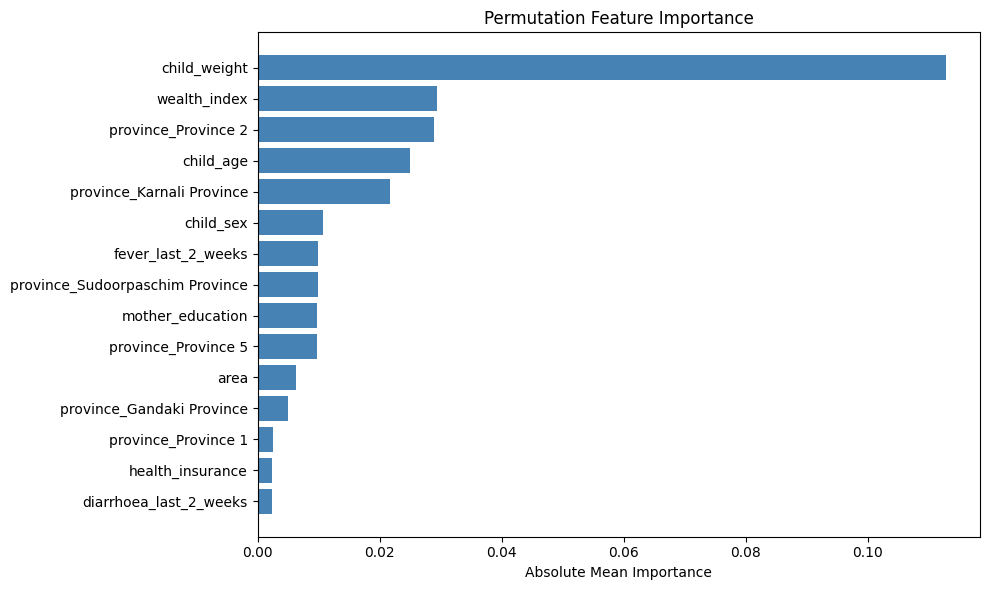

In [14]:
# Compute permutation importance using recall as the scoring metric
result = permutation_importance(
    best_knn,         # Trained KNN model
    X_test,           # Test features
    y_test,           # True labels
    scoring='recall',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create DataFrame with actual and absolute mean importance
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean Importance': result.importances_mean,
    'Abs Mean Importance': np.abs(result.importances_mean),
    'Std Dev': result.importances_std
})

# Sort by absolute importance descending
importance_df = importance_df.sort_values(by='Abs Mean Importance', ascending=False)

# Show table
print(importance_df)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Abs Mean Importance'], color='steelblue')
plt.xlabel("Absolute Mean Importance")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
# from sklearn.inspection import permutation_importance

# # === Step 1: Compute Permutation Importances ===

# # Base KNN
# base_result = permutation_importance(
#     base_knn, X_test, y_test,
#     scoring='recall', n_repeats=10,
#     random_state=42, n_jobs=-1
# )

# # Tuned KNN
# tuned_result = permutation_importance(
#     best_knn, X_test, y_test,
#     scoring='recall', n_repeats=10,
#     random_state=42, n_jobs=-1
# )

# # === Step 2: Create DataFrames ===
# base_importance_df = pd.DataFrame({
#     'Feature': X_test.columns,
#     'Base': base_result.importances_mean
# })

# tuned_importance_df = pd.DataFrame({
#     'Feature': X_test.columns,
#     'Tuned': tuned_result.importances_mean
# })

# # Merge and melt for plotting
# importance_df = pd.merge(base_importance_df, tuned_importance_df, on='Feature')
# importance_df['Abs_Tuned'] = importance_df['Tuned'].abs()

# # Top 10 features by absolute tuned importance
# top_features = importance_df.sort_values(by='Abs_Tuned', ascending=False).head(10)
# melted_df = top_features.melt(id_vars='Feature', value_vars=['Base', 'Tuned'],
#                               var_name='Model', value_name='Importance')

# # Sort feature order for consistent plotting
# feature_order = top_features.sort_values(by='Abs_Tuned', ascending=False)['Feature']

# # === Step 3: Plot ===
# sns.set_style("white")
# plt.figure(figsize=(10, 6))

# ax = sns.barplot(
#     data=melted_df,
#     y='Feature',
#     x='Importance',
#     hue='Model',
#     order=feature_order,
#     palette=['#1f77b4', '#ff7f0e'],  # Base = blue, Tuned = orange
#     orient='h'
# )

# # Vertical line at x = 0
# plt.axvline(x=0, color='black', linewidth=1)

# # Titles and axis labels
# plt.title("Top 10 Permutation Feature Importances (Recall)\nBase KNN vs Tuned KNN", fontsize=14, weight='bold')
# plt.xlabel("Mean Importance (signed)", fontsize=12)
# plt.ylabel("Feature", fontsize=12)
# plt.yticks(fontsize=12)

# # Remove grid and spines
# ax.grid(False)
# sns.despine(left=True, bottom=True)

# # Annotate bars with values
# for i, row in melted_df.iterrows():
#     imp = row['Importance']
#     feature = row['Feature']
#     model = row['Model']
#     idx = list(feature_order).index(feature)
#     offset = 0.0015 if imp >= 0 else -0.002
#     ax.text(imp + offset, idx + (0.2 if model == 'Base' else -0.2), f'{imp:.3f}',
#             ha='left' if imp >= 0 else 'right', va='center', fontsize=8)

# # Legend and layout
# plt.legend(title='Model', loc='best', frameon=False)
# plt.tight_layout()
# plt.show()


#### Alternative (Wilson method) for 95% CI 

In [16]:
# from statsmodels.stats.proportion import proportion_confint

# # Compute recall
# recall = recall_score(y_test, y_pred_tuned)

# # True positives and actual positives
# tp = sum((y_test == 1) & (y_pred_tuned == 1))
# total = sum(y_test == 1)

# # 95% CI using Wilson method
# lower, upper = proportion_confint(tp, total, alpha=0.05, method='wilson')
# print(f"Recall: {recall:.3f}, 95% CI: [{lower:.3f}, {upper:.3f}]")


### Average precision plot

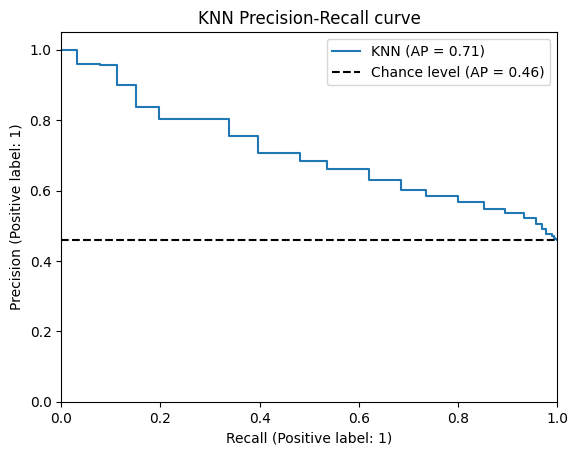

In [17]:
display = PrecisionRecallDisplay.from_estimator(
    best_knn,            # Trained model
    X_test,              # Test features
    y_test,              # True labels
    name="KNN",          # Name for legend
    plot_chance_level=True  # Automatically plots chance-level baseline
)

display.ax_.set_title("KNN Precision-Recall curve")
display.ax_.legend(loc='upper right')
display.ax_.set_xlim([0.0, 1.0])
display.ax_.set_ylim([0.0, 1.05])
plt.show()


## Additional

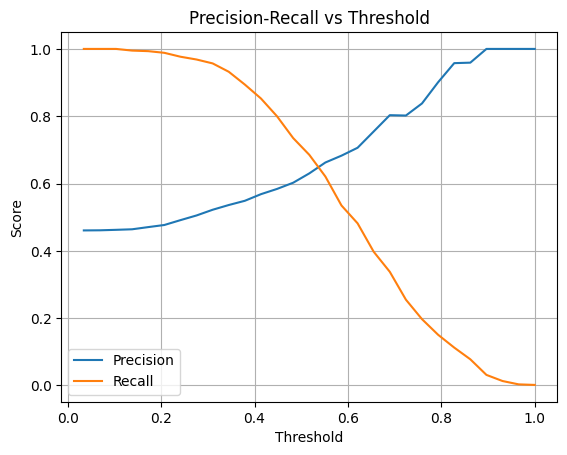

In [18]:
y_proba_tune = best_knn.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_tune)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [19]:
# Apply custom threshold
y_proba_custom = (y_proba_tune >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_proba_custom, digits = 3)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0      0.780     0.447     0.568       707
           1      0.568     0.853     0.682       604

    accuracy                          0.634      1311
   macro avg      0.674     0.650     0.625      1311
weighted avg      0.683     0.634     0.621      1311


